# Regional Metrics — Disruption and Recovery from Saved Baselines

**Prerequisite**: Run `regional_baseline.ipynb` first to generate baseline CSVs.

**Computes** (from saved baseline predictions, no SARIMAX re-fitting):
1. **Largest drop** (within, inflow): max negative deviation in [landing, landing+6d]
2. **Recovery time** (within, inflow): trend-based Theil-Sen recovery from landing
3. **Outflow increase**: max positive deviation in [landing-3d, landing+6d]
4. **Total disruption**: |largest_drop| x recovery_days

**Outputs**:
- Per-category metric plots (relative difference + recovery annotation)
- Comparison bar charts across categories x hurricanes
- Summary CSV

In [1]:
import pandas as pd
import numpy as np
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import theilslopes

warnings.filterwarnings('ignore')

BASELINE_ROOT = '../results/regional_level'

HURRICANE_CONFIGS = {
    'milton': {'landing_date': pd.Timestamp('2024-10-09')},
    'helene': {'landing_date': pd.Timestamp('2024-09-26')},
}

FLOW_TYPES = ['within', 'inflow', 'outflow']

GROUPS = ['Travel', 'Work_and_Professional', 'Health', 'Education',
          'Retail_and_Leisure', 'Urban_Government', 'Utilities']
GROUP_DISPLAY = {
    'Travel': 'Travel',
    'Work_and_Professional': 'Work & Professional',
    'Health': 'Health',
    'Education': 'Education',
    'Retail_and_Leisure': 'Retail & Leisure',
    'Urban_Government': 'Urban Government',
    'Utilities': 'Utilities',
}

print('Setup complete.')

Setup complete.


In [2]:
# ── Load all baselines from CSVs ──
baselines = {}  # (hurricane, flow, category) -> DataFrame

for hrc_name in HURRICANE_CONFIGS:
    hrc_dir = f'{BASELINE_ROOT}/{hrc_name}'
    for ft in FLOW_TYPES:
        for cat in GROUPS:
            csv_path = f'{hrc_dir}/baseline_{ft}_{cat}.csv'
            if os.path.exists(csv_path):
                df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
                baselines[(hrc_name, ft, cat)] = df
            else:
                print(f'  MISSING: {csv_path}')

print(f'Loaded {len(baselines)} baselines')
print(f'Expected: {len(HURRICANE_CONFIGS) * len(FLOW_TYPES) * len(GROUPS)} = '
      f'{len(HURRICANE_CONFIGS)}H x {len(FLOW_TYPES)}F x {len(GROUPS)}C')

Loaded 42 baselines
Expected: 42 = 2H x 3F x 7C


## 1. Metric Functions

In [3]:
def compute_relative_deviation(df):
    """Compute (true - pred) / pred as percentage."""
    eps = 1e-12
    denom = df['y_pred'].replace(0, np.nan) + eps
    rel_diff = (df['y_true'] - df['y_pred']) / denom * 100
    rel_lower = (df['ci_lower'] - df['y_pred']) / denom * 100
    rel_upper = (df['ci_upper'] - df['y_pred']) / denom * 100
    return rel_diff, rel_lower, rel_upper


def compute_largest_drop(rel_diff, landing_date, window_days=6):
    """Largest negative deviation in [landing, landing+window_days]."""
    start = landing_date
    end = landing_date + pd.Timedelta(days=window_days)
    window = rel_diff.loc[(rel_diff.index >= start) & (rel_diff.index <= end)]
    if window.empty:
        return None, None
    drop_val = window.min()
    drop_date = window.idxmin()
    return float(drop_val), drop_date


def compute_outflow_increase(rel_diff, landing_date, pre_days=3, post_days=6):
    """Largest positive deviation in [landing-pre_days, landing+post_days]."""
    start = landing_date - pd.Timedelta(days=pre_days)
    end = landing_date + pd.Timedelta(days=post_days)
    window = rel_diff.loc[(rel_diff.index >= start) & (rel_diff.index <= end)]
    if window.empty:
        return None, None
    inc_val = window.max()
    inc_date = window.idxmax()
    return float(inc_val), inc_date


def trend_based_recovery(rel_diff, landing_date, smooth_window=3, trough_search_days=7):
    """Trend-based recovery with Theil-Sen slope. Returns dict."""
    rd_smooth = rel_diff.rolling(window=smooth_window, center=True, min_periods=1).mean()
    
    # Find trough within search window
    trough_end = landing_date + pd.Timedelta(days=trough_search_days)
    search = rd_smooth.loc[(rd_smooth.index >= landing_date) & (rd_smooth.index <= trough_end)]
    
    if search.empty or search.min() >= 0:
        return {'trough_date': None, 'recovery_days': None, 'recovery_date': None,
                'slope': None, 'intercept': None, 'rd_smooth': rd_smooth,
                'reason': 'No negative deviation found'}
    
    trough_date = search.idxmin()
    
    # Monotonic recovery segment
    post_trough = rd_smooth.loc[rd_smooth.index >= trough_date]
    vals = post_trough.values
    mono_end = 1
    for i in range(1, len(vals)):
        if vals[i] >= vals[i-1] - 1e-15:
            mono_end = i + 1
        else:
            break
    mono_segment = post_trough.iloc[:mono_end]
    
    if len(mono_segment) < 2:
        return {'trough_date': trough_date, 'recovery_days': None, 'recovery_date': None,
                'slope': None, 'intercept': None, 'rd_smooth': rd_smooth,
                'mono_segment': mono_segment, 'reason': 'Mono segment too short'}
    
    # Theil-Sen slope
    t = np.arange(len(mono_segment), dtype=float)
    slope, intercept, lo_slope, hi_slope = theilslopes(mono_segment.values, t)
    
    if slope <= 0:
        return {'trough_date': trough_date, 'recovery_days': None, 'recovery_date': None,
                'slope': float(slope), 'intercept': float(intercept),
                'rd_smooth': rd_smooth, 'mono_segment': mono_segment,
                'reason': 'Slope <= 0'}
    
    tau_from_trough = -intercept / slope
    recovery_date = trough_date + pd.to_timedelta(tau_from_trough, unit='D')
    days_landing_to_trough = (trough_date - landing_date).days
    recovery_days = days_landing_to_trough + tau_from_trough
    
    return {
        'trough_date': trough_date,
        'recovery_days': float(recovery_days),
        'recovery_date': recovery_date,
        'slope': float(slope),
        'intercept': float(intercept),
        'slope_ci': (float(lo_slope), float(hi_slope)),
        'days_landing_to_trough': days_landing_to_trough,
        'tau_from_trough': float(tau_from_trough),
        'rd_smooth': rd_smooth,
        'mono_segment': mono_segment,
    }

print('Metric functions defined.')

Metric functions defined.


## 2. Compute All Metrics

In [4]:
# ── Compute metrics for all baselines ──
all_metrics = []

for hrc_name, hrc_cfg in HURRICANE_CONFIGS.items():
    landing = hrc_cfg['landing_date']
    fig_dir = f'{BASELINE_ROOT}/{hrc_name}/figures'
    os.makedirs(fig_dir, exist_ok=True)
    
    print(f"\n{'='*70}")
    print(f'{hrc_name.upper()} (landing: {landing.date()})')
    print(f"{'='*70}")
    
    for ft in FLOW_TYPES:
        for cat in GROUPS:
            key = (hrc_name, ft, cat)
            if key not in baselines:
                continue
            
            df = baselines[key]
            cat_display = GROUP_DISPLAY[cat]
            rel_diff, rel_lower, rel_upper = compute_relative_deviation(df)
            
            row = {
                'hurricane': hrc_name,
                'flow_type': ft,
                'category': cat_display,
            }
            
            # Largest drop (within and inflow)
            drop_val, drop_date = compute_largest_drop(rel_diff, landing)
            row['largest_drop'] = drop_val
            row['drop_date'] = drop_date
            
            # Outflow increase
            inc_val, inc_date = compute_outflow_increase(rel_diff, landing)
            row['largest_increase'] = inc_val
            row['increase_date'] = inc_date
            
            # Recovery time (within and inflow only)
            if ft in ['within', 'inflow']:
                rec = trend_based_recovery(rel_diff, landing)
                row['recovery_days'] = rec.get('recovery_days')
                row['recovery_date'] = rec.get('recovery_date')
                row['trough_date'] = rec.get('trough_date')
                row['slope_pct_per_day'] = rec.get('slope', None)
                if rec.get('slope'):
                    row['slope_pct_per_day'] = rec['slope'] * 100
                mono = rec.get('mono_segment')
                rd_smooth = rec.get('rd_smooth')
            else:
                row['recovery_days'] = None
                row['recovery_date'] = None
                row['trough_date'] = None
                row['slope_pct_per_day'] = None
                rec = None
                mono = None
                rd_smooth = None
            
            # Total disruption
            if drop_val is not None and row['recovery_days'] is not None:
                row['total_disruption'] = abs(drop_val) * row['recovery_days']
            else:
                row['total_disruption'] = None
            
            all_metrics.append(row)
            
            # ── Plot: relative difference with annotations ──
            fig, ax = plt.subplots(figsize=(14, 5))
            forecast_idx = df.index
            
            ax.plot(forecast_idx, rel_diff.values, 'k-', lw=1.5, label='Relative diff')
            ax.fill_between(forecast_idx, rel_lower, rel_upper,
                           color='red', alpha=0.1, label='95% CI')
            ax.axhline(0, color='gray', ls='--', lw=1)
            ax.axhline(5, color='red', ls='--', lw=1, alpha=0.5)
            ax.axhline(-5, color='red', ls='--', lw=1, alpha=0.5)
            ax.axvline(landing, color='blue', ls='--', lw=2, label='Landing')
            
            # Annotate drop
            if drop_val is not None:
                ax.plot(drop_date, drop_val, 'rv', ms=12, zorder=10, label=f'Drop: {drop_val:.1f}%')
            
            # Annotate outflow increase
            if ft == 'outflow' and inc_val is not None:
                ax.plot(inc_date, inc_val, 'g^', ms=12, zorder=10, label=f'Increase: {inc_val:.1f}%')
            
            # Annotate recovery
            if rec and rec.get('recovery_date') is not None:
                ax.axvline(rec['recovery_date'], color='green', ls='--', lw=2,
                          label=f'Recovery: {rec["recovery_days"]:.1f}d')
            if rec and rec.get('trough_date') is not None:
                ax.axvline(rec['trough_date'], color='orange', ls='--', lw=2, label='Trough')
            
            # Smoothed + mono segment + Theil-Sen (for within/inflow)
            if rd_smooth is not None:
                ax.plot(rd_smooth.index, rd_smooth.values, 'b-', lw=1, alpha=0.5, label='Smoothed')
            if mono is not None and len(mono) >= 2:
                ax.plot(mono.index, mono.values, 'g-', lw=3, alpha=0.6, label=f'Mono ({len(mono)}d)')
                if rec and rec.get('slope') and rec.get('intercept') is not None:
                    t_fit = np.arange(len(rd_smooth.loc[rd_smooth.index >= rec['trough_date']]))
                    fit_vals = rec['intercept'] + rec['slope'] * t_fit
                    fit_idx = rd_smooth.loc[rd_smooth.index >= rec['trough_date']].index[:len(t_fit)]
                    ax.plot(fit_idx, fit_vals, 'g--', lw=1.5, alpha=0.8, label='Theil-Sen fit')
            
            ax.set_title(f"{hrc_name.capitalize()} — {cat_display} — {ft}\n"
                        f"Relative Difference (True-Pred)/Pred (%)", fontweight='bold')
            ax.set_xlabel('Date')
            ax.set_ylabel('Relative Difference (%)')
            ax.legend(fontsize=8, loc='best')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(f'{fig_dir}/metrics_{ft}_{cat}.png', dpi=150, bbox_inches='tight')
            plt.close()
            
            # Print summary
            rec_str = f"{row['recovery_days']:.1f}d" if row['recovery_days'] else 'N/A'
            drop_str = f"{drop_val:.1f}%" if drop_val else 'N/A'
            inc_str = f"{inc_val:.1f}%" if inc_val else 'N/A'
            print(f'  [{ft}] {cat_display}: drop={drop_str}, recovery={rec_str}, increase={inc_str}')

# Save summary
metrics_df = pd.DataFrame(all_metrics)
metrics_df.to_csv(f'{BASELINE_ROOT}/regional_metrics_summary.csv', index=False)
print(f'\nSaved: {BASELINE_ROOT}/regional_metrics_summary.csv ({len(metrics_df)} rows)')


MILTON (landing: 2024-10-09)
  [within] Travel: drop=-48.6%, recovery=4.8d, increase=15.3%
  [within] Work & Professional: drop=-37.2%, recovery=4.8d, increase=16.1%
  [within] Health: drop=-25.1%, recovery=4.5d, increase=21.3%
  [within] Education: drop=-35.0%, recovery=6.3d, increase=10.6%
  [within] Retail & Leisure: drop=-33.1%, recovery=5.2d, increase=13.5%
  [within] Urban Government: drop=-29.4%, recovery=4.9d, increase=14.5%
  [within] Utilities: drop=-40.3%, recovery=4.2d, increase=19.9%
  [inflow] Travel: drop=-71.1%, recovery=4.8d, increase=10.8%
  [inflow] Work & Professional: drop=-50.2%, recovery=5.6d, increase=14.4%
  [inflow] Health: drop=-30.8%, recovery=4.7d, increase=17.3%
  [inflow] Education: drop=-34.5%, recovery=4.9d, increase=15.1%
  [inflow] Retail & Leisure: drop=-51.5%, recovery=5.6d, increase=5.8%
  [inflow] Urban Government: drop=-50.1%, recovery=5.2d, increase=16.5%
  [inflow] Utilities: drop=-55.3%, recovery=4.1d, increase=50.0%
  [outflow] Travel: drop=

## 3. Display Summary Table

In [5]:
# ── Summary table ──
display_cols = ['hurricane', 'flow_type', 'category', 'largest_drop', 'recovery_days',
                'largest_increase', 'total_disruption']
summary = metrics_df[display_cols].copy()
summary = summary.round(2)

print('\nWithin flow:')
display(summary[summary['flow_type'] == 'within'].drop(columns='flow_type'))

print('\nInflow:')
display(summary[summary['flow_type'] == 'inflow'].drop(columns='flow_type'))

print('\nOutflow:')
display(summary[summary['flow_type'] == 'outflow'].drop(columns='flow_type'))


Within flow:


,hurricane,category,largest_drop,recovery_days,largest_increase,total_disruption
0,milton,Travel,-48.62,4.83,15.28,234.70
1,milton,Work & Professional,-37.23,4.79,16.11,178.29
2,milton,Health,-25.11,4.55,21.31,114.24
3,milton,Education,-34.95,6.31,10.60,220.59
4,milton,Retail & Leisure,-33.09,5.16,13.45,170.65
5,milton,Urban Government,-29.38,4.93,14.54,144.93
6,milton,Utilities,-40.30,4.24,19.92,171.00
21,helene,Travel,-12.15,4.43,7.93,53.84
22,helene,Work & Professional,-12.58,4.29,6.09,53.92
23,helene,Health,-10.04,4.11,8.35,41.29



Inflow:


,hurricane,category,largest_drop,recovery_days,largest_increase,total_disruption
7,milton,Travel,-71.13,4.80,10.80,341.24
8,milton,Work & Professional,-50.16,5.56,14.44,278.97
9,milton,Health,-30.78,4.68,17.34,144.04
10,milton,Education,-34.49,4.86,15.05,167.59
11,milton,Retail & Leisure,-51.47,5.57,5.80,286.95
12,milton,Urban Government,-50.09,5.16,16.53,258.71
13,milton,Utilities,-55.29,4.08,50.03,225.71
28,helene,Travel,-17.99,11.20,14.50,201.46
29,helene,Work & Professional,-18.58,11.98,21.61,222.68
30,helene,Health,-17.83,12.05,17.76,214.96



Outflow:


,hurricane,category,largest_drop,recovery_days,largest_increase,total_disruption
14,milton,Travel,-2.97,NaN,35.53,NaN
15,milton,Work & Professional,3.33,NaN,41.38,NaN
16,milton,Health,5.26,NaN,39.84,NaN
17,milton,Education,1.49,NaN,32.40,NaN
18,milton,Retail & Leisure,2.73,NaN,56.23,NaN
19,milton,Urban Government,6.89,NaN,51.07,NaN
20,milton,Utilities,36.54,NaN,132.32,NaN
35,helene,Travel,-10.69,NaN,13.51,NaN
36,helene,Work & Professional,-14.33,NaN,15.78,NaN
37,helene,Health,-13.93,NaN,10.95,NaN


## 4. Comparison Bar Charts — Across Categories x Hurricanes

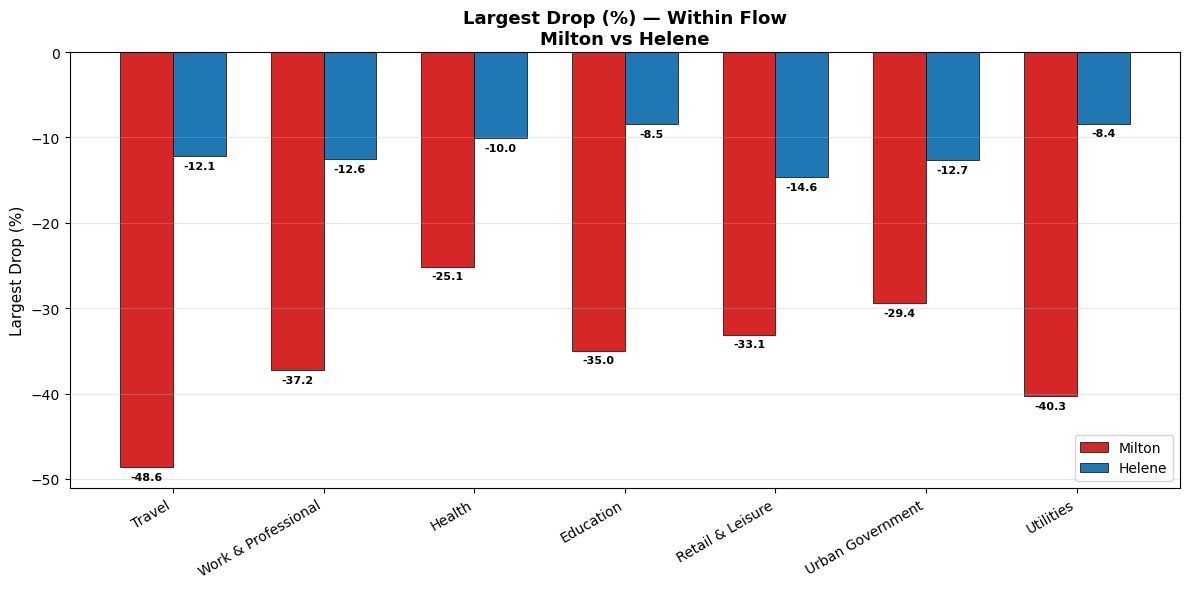

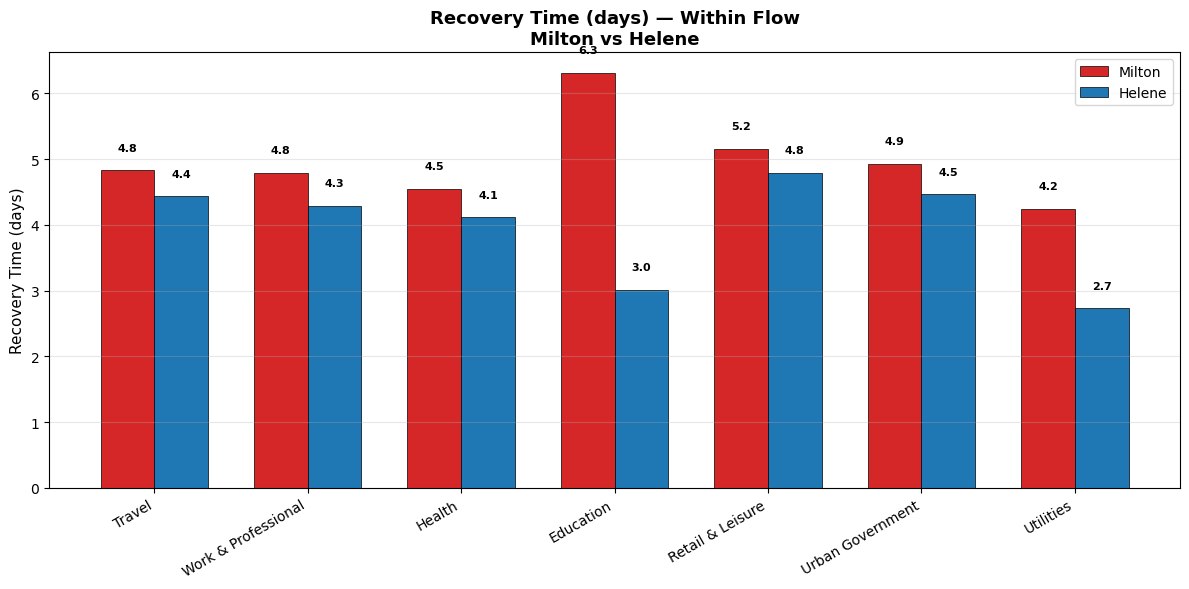

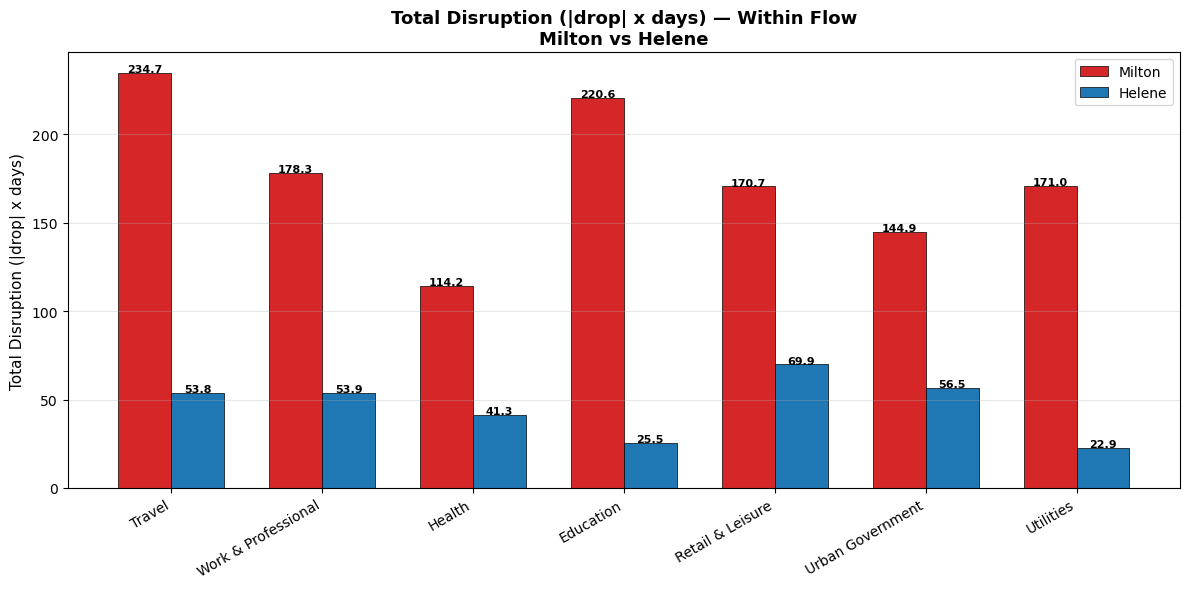

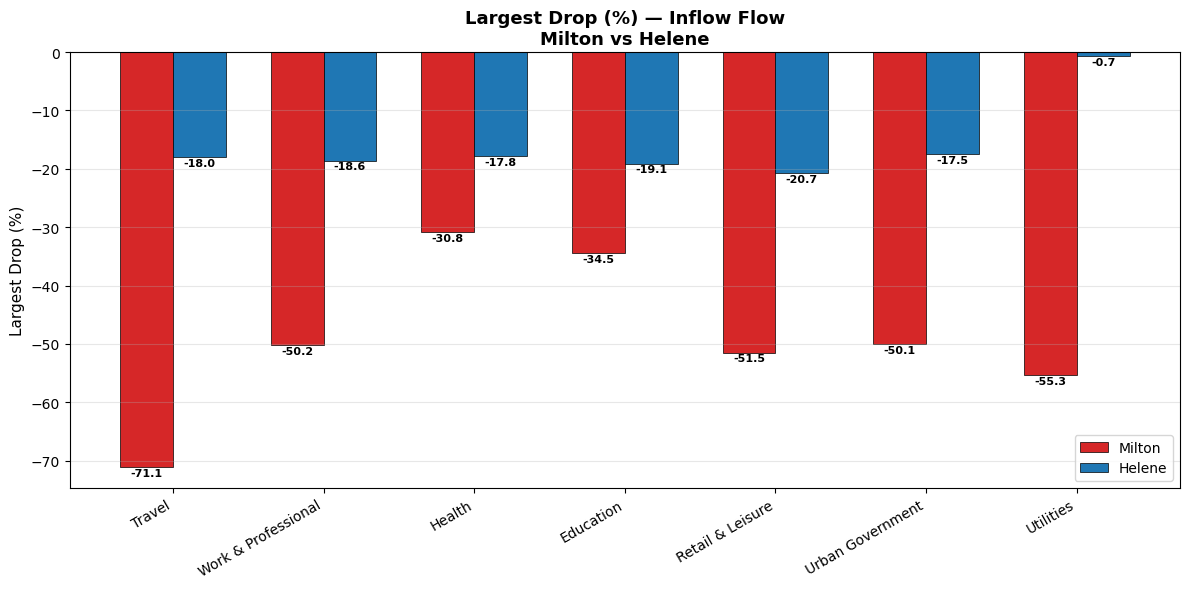

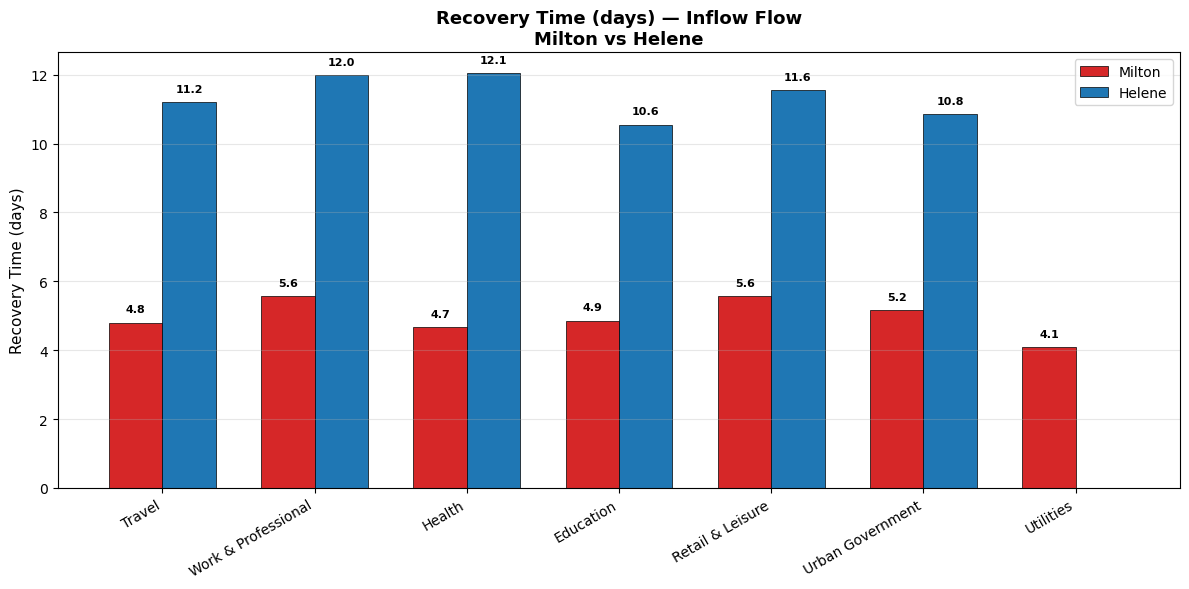

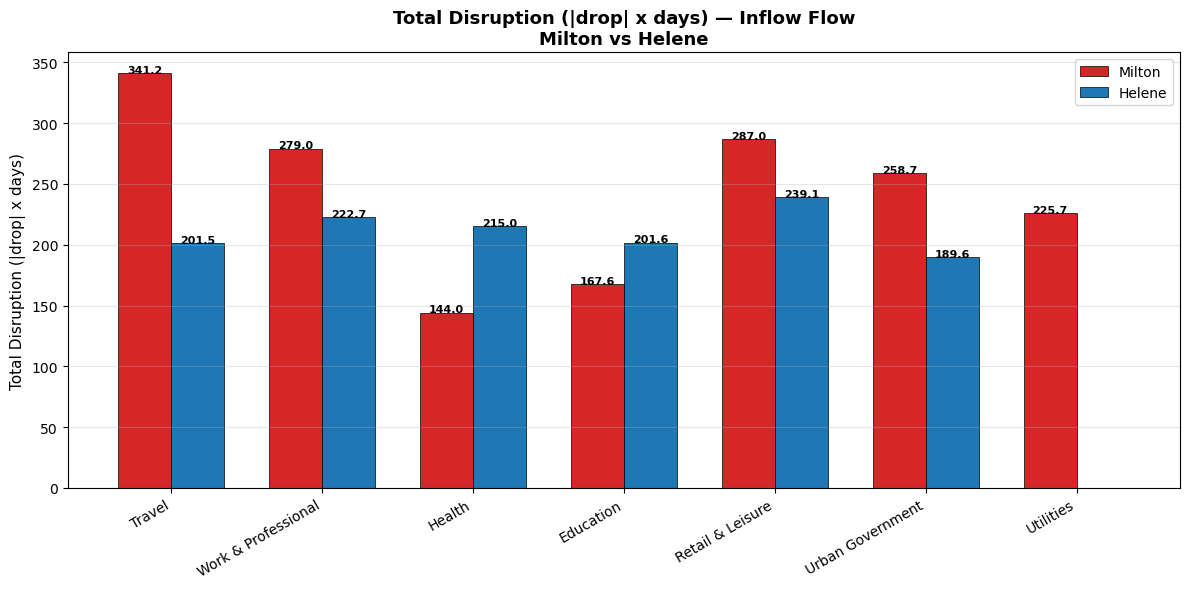

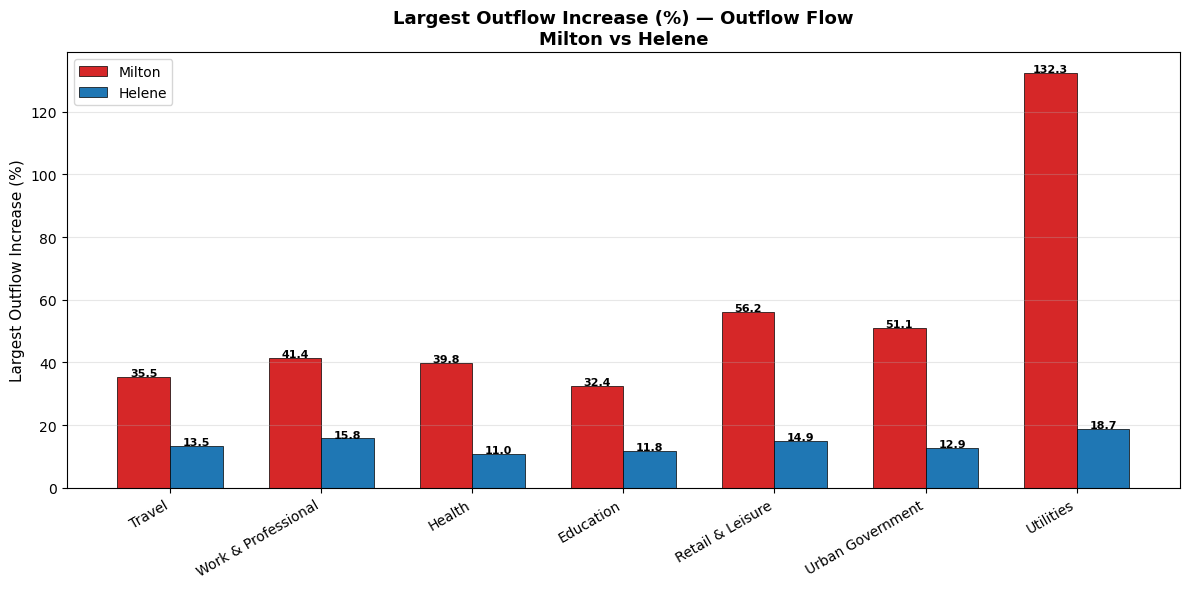

In [6]:
# ── Bar charts: compare Milton vs Helene for each metric ──
colors_hrc = {'milton': '#d62728', 'helene': '#1f77b4'}

def plot_comparison_bars(metrics_df, dv_col, dv_label, flow_type, save_path):
    """Grouped bar chart comparing hurricanes for a given metric and flow type."""
    sub = metrics_df[metrics_df['flow_type'] == flow_type].copy()
    if sub.empty:
        return
    
    categories = list(GROUP_DISPLAY.values())
    x = np.arange(len(categories))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for i, hrc in enumerate(HURRICANE_CONFIGS.keys()):
        hrc_sub = sub[sub['hurricane'] == hrc].set_index('category')
        vals = []
        for cat in categories:
            v = hrc_sub.loc[cat, dv_col] if cat in hrc_sub.index and pd.notna(hrc_sub.loc[cat, dv_col]) else 0
            vals.append(v)
        offset = -width/2 + i * width
        bars = ax.bar(x + offset, vals, width, label=hrc.capitalize(),
                      color=colors_hrc[hrc], edgecolor='black', linewidth=0.5)
        # Label values
        for j, v in enumerate(vals):
            if v != 0:
                ax.text(x[j] + offset, v + (0.3 if v > 0 else -1.5),
                       f'{v:.1f}', ha='center', fontsize=8, fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=30, ha='right', fontsize=10)
    ax.set_ylabel(dv_label, fontsize=11)
    ax.set_title(f'{dv_label} — {flow_type.capitalize()} Flow\nMilton vs Helene',
                fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(0, color='gray', lw=0.5)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


comp_fig_dir = f'{BASELINE_ROOT}/comparison_figures'
os.makedirs(comp_fig_dir, exist_ok=True)

# Within flow comparisons
plot_comparison_bars(metrics_df, 'largest_drop', 'Largest Drop (%)', 'within',
                    f'{comp_fig_dir}/compare_drop_within.png')
plot_comparison_bars(metrics_df, 'recovery_days', 'Recovery Time (days)', 'within',
                    f'{comp_fig_dir}/compare_recovery_within.png')
plot_comparison_bars(metrics_df, 'total_disruption', 'Total Disruption (|drop| x days)', 'within',
                    f'{comp_fig_dir}/compare_disruption_within.png')

# Inflow comparisons
plot_comparison_bars(metrics_df, 'largest_drop', 'Largest Drop (%)', 'inflow',
                    f'{comp_fig_dir}/compare_drop_inflow.png')
plot_comparison_bars(metrics_df, 'recovery_days', 'Recovery Time (days)', 'inflow',
                    f'{comp_fig_dir}/compare_recovery_inflow.png')
plot_comparison_bars(metrics_df, 'total_disruption', 'Total Disruption (|drop| x days)', 'inflow',
                    f'{comp_fig_dir}/compare_disruption_inflow.png')

# Outflow increase
plot_comparison_bars(metrics_df, 'largest_increase', 'Largest Outflow Increase (%)', 'outflow',
                    f'{comp_fig_dir}/compare_increase_outflow.png')

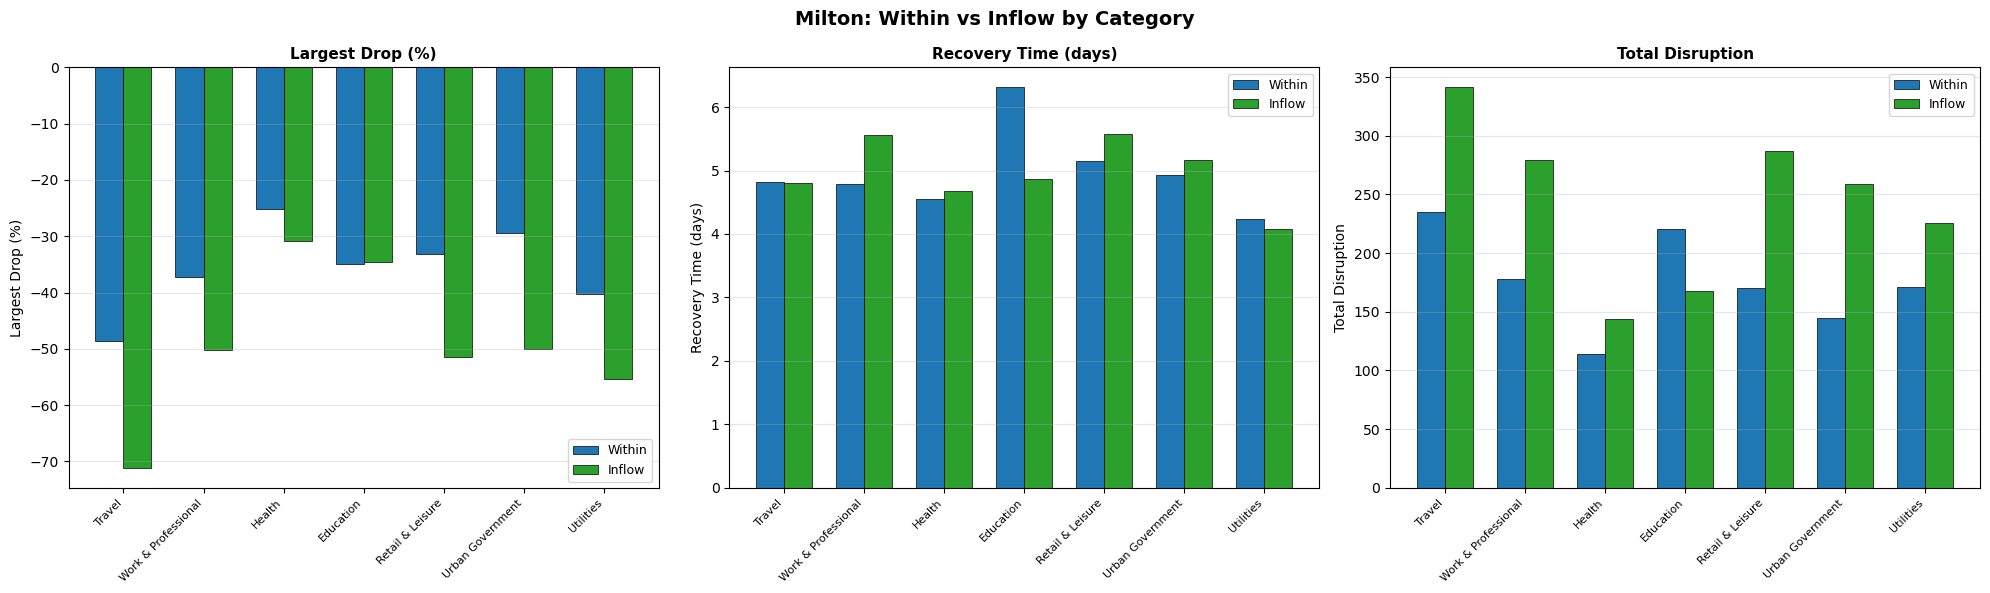

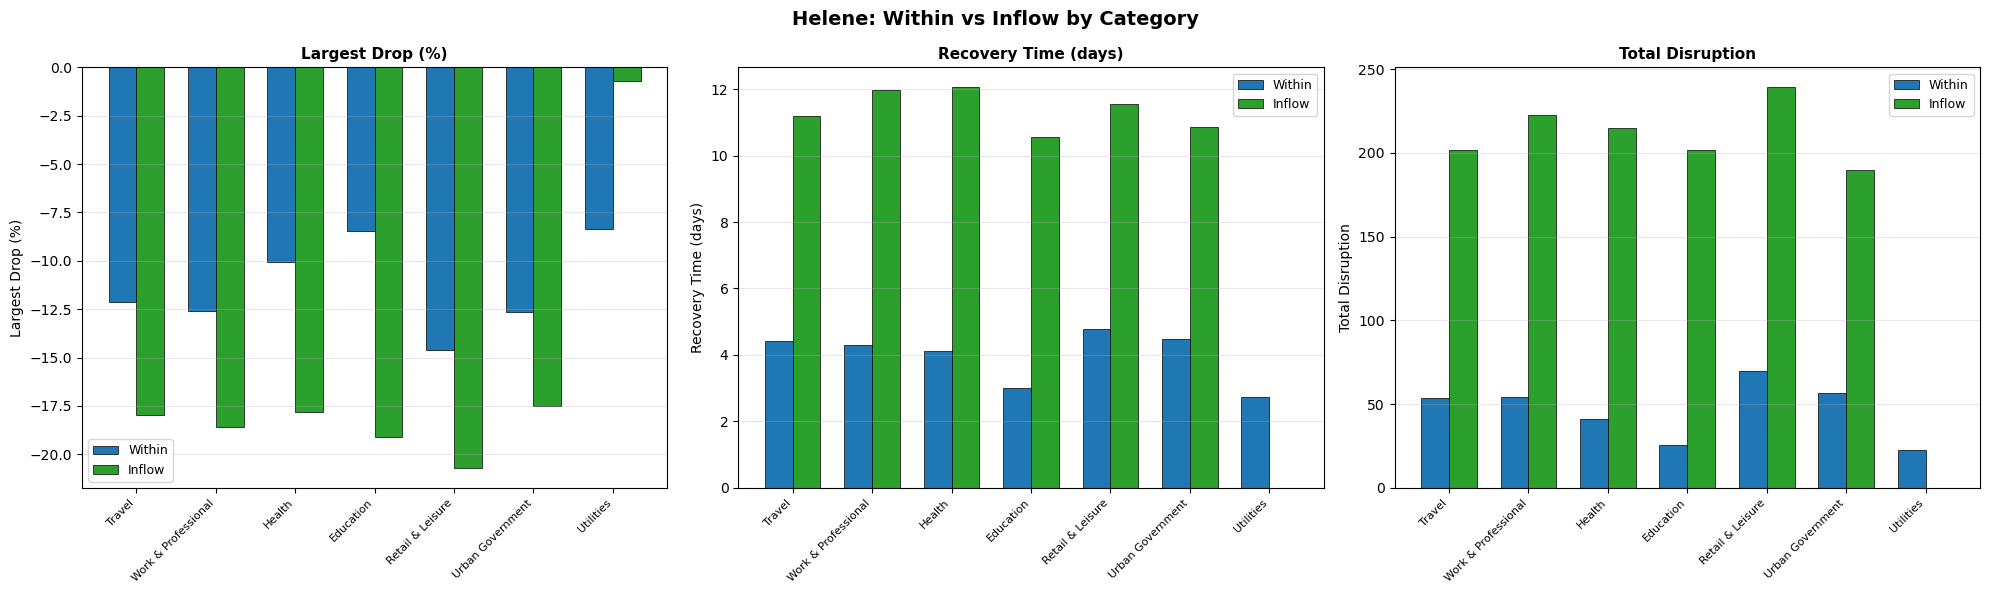

In [7]:
# ── Cross-flow comparison: Within vs Inflow for each hurricane ──
for hrc_name in HURRICANE_CONFIGS:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    hrc_sub = metrics_df[metrics_df['hurricane'] == hrc_name]
    categories = list(GROUP_DISPLAY.values())
    x = np.arange(len(categories))
    width = 0.35
    
    ft_colors = {'within': '#1f77b4', 'inflow': '#2ca02c'}
    
    for ax, (dv_col, dv_label) in zip(axes, [
        ('largest_drop', 'Largest Drop (%)'),
        ('recovery_days', 'Recovery Time (days)'),
        ('total_disruption', 'Total Disruption'),
    ]):
        for i, ft in enumerate(['within', 'inflow']):
            ft_sub = hrc_sub[hrc_sub['flow_type'] == ft].set_index('category')
            vals = []
            for cat in categories:
                v = ft_sub.loc[cat, dv_col] if cat in ft_sub.index and pd.notna(ft_sub.loc[cat, dv_col]) else 0
                vals.append(v)
            offset = -width/2 + i * width
            ax.bar(x + offset, vals, width, label=ft.capitalize(),
                  color=ft_colors[ft], edgecolor='black', linewidth=0.5)
        
        ax.set_xticks(x)
        ax.set_xticklabels(categories, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel(dv_label, fontsize=10)
        ax.set_title(dv_label, fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        ax.axhline(0, color='gray', lw=0.5)
    
    fig.suptitle(f'{hrc_name.capitalize()}: Within vs Inflow by Category',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{comp_fig_dir}/crossflow_{hrc_name}.png', dpi=150, bbox_inches='tight')
    plt.show()